# Task 1

In [58]:
import pandas as pd
from sklearn.linear_model import LinearRegression

insurance_df = pd.read_csv('data/insurance.csv')

X = insurance_df[['age','bmi','children']]
y = insurance_df['charges']

ins_all_model = LinearRegression()
ins_all_model.fit(X,y)

print(f'R2 Score (Entire Dataset):  {ins_all_model.score(X,y):.2f}')

R2 Score (Entire Dataset):  0.12


This score is an estimate of how close we are to the actual values and describes how much of the variation in the dataset our model accounts for. This score is very low, meaning our model is not good.

# Task 2

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ins_split_model = LinearRegression()
ins_split_model.fit(X_train, y_train)

print(
    f'Training R2: {ins_split_model.score(X_train, y_train)} \n'
    f'Testing R2:  {ins_split_model.score(X_test, y_test)}'
)

Training R2: 0.10987471044767116 
Testing R2:  0.15489592484270753


They are relatively close, but still both scoring pretty low. The Testing R2 is a more honest measure of performance because it is using data that the model wasn't trained on, keeping it from learning too much about the data before outputting predictions.

# Task 3

In [60]:
from sklearn.tree import DecisionTreeRegressor

cars_df = pd.read_csv('data/cars.csv')
cars_df = cars_df.dropna()

cars_X = cars_df[['weight']]
cars_y = cars_df['mpg']

cars_X_train, cars_X_test, cars_y_train, cars_y_test = train_test_split(
    cars_X, cars_y, test_size=.2, random_state=42
)


depths = [1, 5, 50]

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(cars_X_train, cars_y_train)
    train_score = round(dt.score(cars_X_train, cars_y_train), 2)
    test_score = round(dt.score(cars_X_test, cars_y_test),2)    
    print(f'Depth: {depth:>2}  ||  Training Score: {train_score}  ||  Test Score: {test_score}')

Depth:  1  ||  Training Score: 0.55  ||  Test Score: 0.56
Depth:  5  ||  Training Score: 0.79  ||  Test Score: 0.76
Depth: 50  ||  Training Score: 0.97  ||  Test Score: 0.63


The Training Score goes way up and test score way down at depth of 50. This is called overfitting.  
When both scores are low, it is called underfitting.

# Task 4

In [61]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=.25, random_state=42)

ins_val_model = LinearRegression()
ins_val_model.fit(X_train, y_train)

val_score = ins_val_model.score(X_val, y_val)
val_training_score = ins_val_model.score(X_train, y_train)

print("training score:", val_training_score)
print("Val Score: ", val_score)

# We  need the validation score the test our model and fix it. We look at the test score once
#when we think we are done fixing it.

training score: 0.0991317384737409
Val Score:  0.1258318862732275


In [62]:
from sklearn.model_selection import KFold, cross_val_score

salary_df = pd.read_csv("Data/Salary.csv")

salary_X = salary_df[["YearsExperience"]]
salary_y = salary_df["Salary"]

salary_model = LinearRegression()

salary_bad_val = cross_val_score(salary_model, salary_X, salary_y, cv=5, scoring="r2")

print("salary_bad_val mean:", salary_bad_val.mean())
print("salary_bad_val:", salary_bad_val)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

salary_good_val = cross_val_score(salary_model, salary_X, salary_y, cv=kf, scoring="r2")

print("salary_good_val mean:", salary_good_val.mean())
print("salary_good_val:", salary_good_val)

#Yes shuffling the data changes the mean score by a lot. If the data is sorted then the folds
#looking at the top and bottom of the data set will be very different.

salary_bad_val mean: -0.05336427684509828
salary_bad_val: [ 0.3595933  -1.24422823  0.25052696  0.29699762  0.07028896]
salary_good_val mean: 0.922415665403513
salary_good_val: [0.90244618 0.96846325 0.91621488 0.98161851 0.84333552]


# Task 6

1. Train/Test split, because we are using a small data set and don't have to make any decisions on the model.
2. Three-way split because it is a big data set.
3. train/test split because everything is done and you just want an honest score.
4. cross-validation because it has less than 1000 rows and you still want to tune it.

# Advanced Task 1

In [63]:
# The test set should be the last step after making a decision on what model you are going to use 
# after all validations are done.

In [64]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=.25, random_state=42)

ins_model_lr = LinearRegression()
ins_model_dt = DecisionTreeRegressor(max_depth=5, random_state=42)

ins_model_lr.fit(X_train, y_train)
ins_model_dt.fit(X_train, y_train)

val_score_lr = ins_model_lr.score(X_val, y_val)
val_score_dt = ins_model_dt.score(X_val, y_val)

print("LR validation: ", val_score_lr)
print("DT validation: ", val_score_dt)

ins_model_lr_score = ins_model_lr.score(X_test, y_test)

print("Final Score: ", ins_model_lr_score)


LR validation:  0.1258318862732275
DT validation:  0.05622464364124535
Final Score:  0.1495866049835689


# Advanced Task 2

In [65]:
# training_r2 = []
# test_r2 = []
training_r2 = {}
test_r2 = {}

for depth in range(1,16):
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(cars_X_train, cars_y_train)
    # training_r2.append((depth, model.score(cars_X_train, cars_y_train)))
    # test_r2.append((depth, model.score(cars_X_test, cars_y_test)))
    # training_r2.append((model.score(cars_X_train, cars_y_train)))
    # test_r2.append((model.score(cars_X_test, cars_y_test)))
    training_r2[depth] = (model.score(cars_X_train, cars_y_train))
    test_r2[depth] = (model.score(cars_X_test, cars_y_test))

print(training_r2)
print(test_r2)

# training_r2_df = pd.DataFrame(training_r2)
# test_r2_df = pd.DataFrame(test_r2)

{1: 0.5548819464368954, 2: 0.6933285048921451, 3: 0.723258529409381, 4: 0.7582046730226637, 5: 0.7931375480154041, 6: 0.8257316036884399, 7: 0.851761735744325, 8: 0.8762722693672862, 9: 0.9051206605405643, 10: 0.9227090403081136, 11: 0.9433412000999369, 12: 0.954705688456169, 13: 0.9638765981469546, 14: 0.9661033346388873, 15: 0.966591261881845}
{1: 0.5555627772981998, 2: 0.7526982170385568, 3: 0.7524295763477784, 4: 0.7717886120885765, 5: 0.759551334479482, 6: 0.7772996203711036, 7: 0.7498600313750875, 8: 0.7657052343596036, 9: 0.7375889880324853, 10: 0.7112405066458374, 11: 0.7054564759090847, 12: 0.6651081925466239, 13: 0.637643866032251, 14: 0.6266774535475124, 15: 0.626314773804536}


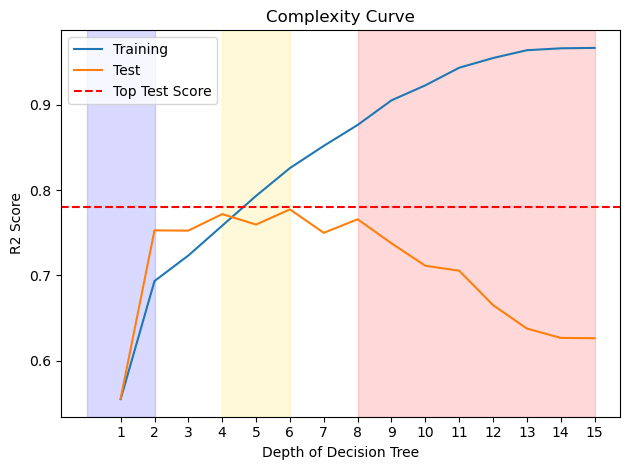

In [89]:
import matplotlib.pyplot as plt

plt.plot(list(training_r2.keys()), list(training_r2.values()), label='Training')
plt.plot(list(test_r2.keys()), list(test_r2.values()), label='Test')
plt.xticks(range(1,16))

plt.axvspan(0, 2, color='blue', alpha=0.15) # Underfit
plt.axvspan(4,6, color='gold', alpha=0.15)  # Sweet spot 
plt.axvspan(8,15, color='red', alpha=0.15)  # Overfit
plt.axhline(y=0.78, color='red', linestyle = '--', label='Top Test Score')


plt.legend(loc='upper left')
plt.xlabel('Depth of Decision Tree')
plt.ylabel('R2 Score')


plt.title('Complexity Curve')
plt.tight_layout()
plt.show()

# Extra Credit

In [ ]:
def select_best_depth(X, y, depths):
    best_depth = 0
    best_score = -1
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=.25, random_state=42)

    for depth in depths:
        model = DecisionTreeRegressor(max_depth=depth, random_state=42)
        model.fit(X_train, y_train) 
        val_score = model.score(X_val, y_val)
        print(val_score)
        if val_score > best_score:
            best_score = val_score
            best_depth = depth
    
    best_model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
    best_model.fit(X_train, y_train)
    return f'Best Depth: {best_depth}  ||  Test score: {best_model.score(X_test, y_test):.2f}'

insurance_df = pd.read_csv('data/insurance.csv')

X = insurance_df[['age','bmi','children']]
y = insurance_df['charges']

select_best_depth(X, y, range(1,20))

0.08173671883014078
0.10530017159115213
0.12629401989180733
0.07573234294470199
0.05622464364124535
-0.0068087353675592155
-0.09138011663116963
-0.16134513917218674
-0.24447060590751857
-0.2970870899000897
-0.3894802225062115
-0.3445324005388235
-0.4062206012110181
-0.47994717506564055
-0.48833838739066926
-0.49943458396116935
-0.4523850843497481
-0.4976624800360383
-0.46848375827593314


'Best Depth: 3  ||  Test score: 0.10'